In [20]:
import joblib

# Save trained model
joblib.dump(xgb_model, "../models/xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


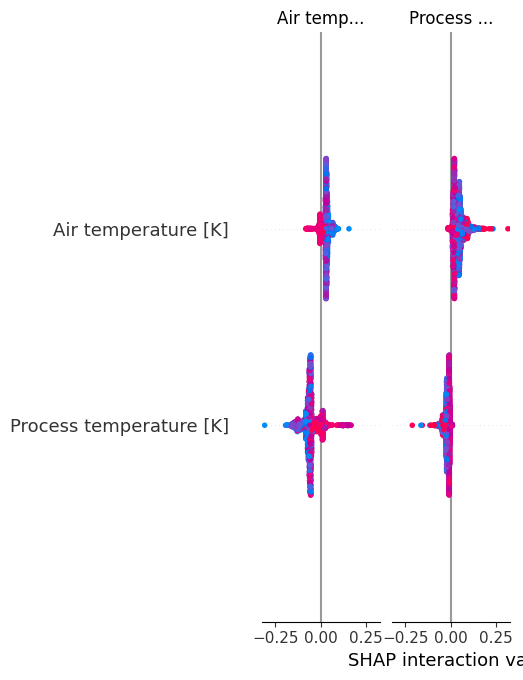

In [19]:
# Better SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

d:\it school ML\smartpredict\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


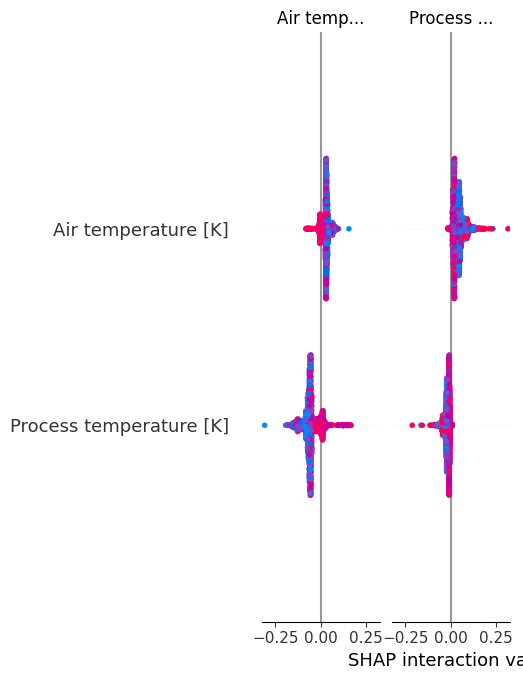

In [18]:
import shap

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [17]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1]
}

# Create base model
xgb_tuned = XGBClassifier(
    scale_pos_weight=28,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Train
grid_search.fit(X_train_clean, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best score
print("\nBest Recall Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Best Recall Score:
0.9520553520553521


In [16]:
from xgboost import XGBClassifier

# Create model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=28,
    random_state=42
)

# Train model
xgb_model.fit(X_train_clean, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_clean)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.9755

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.60      0.82      0.70        68

    accuracy                           0.98      2000
   macro avg       0.80      0.90      0.84      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:

[[1895   37]
 [  12   56]]


In [14]:
# Clean column names for XGBoost compatibility
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean.columns = (
    X_train_clean.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

X_test_clean.columns = (
    X_test_clean.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

print(X_train_clean.columns)

Index(['Air temperature K', 'Process temperature K', 'Rotational speed rpm',
       'Torque Nm', 'Tool wear min', 'Temperature Difference', 'Power',
       'Type_L', 'Type_M'],
      dtype='str')


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.989

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.72      0.82        68

    accuracy                           0.99      2000
   macro avg       0.97      0.86      0.91      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:

[[1929    3]
 [  19   49]]


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9685

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.61      0.21      0.31        68

    accuracy                           0.97      2000
   macro avg       0.79      0.60      0.65      2000
weighted avg       0.96      0.97      0.96      2000


Confusion Matrix:

[[1923    9]
 [  54   14]]


In [10]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop("Machine failure", axis=1)

# Target
y = df["Machine failure"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 9)
X_test shape: (2000, 9)
y_train shape: (8000,)
y_test shape: (2000,)


In [9]:
# One-Hot Encoding for Type column
df = pd.get_dummies(df,
                    columns=["Type"],
                    drop_first=True)

# Show first rows
print(df.head())

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  Temperature Difference  \
0         42.8                0                0                    10.5   
1         46.3                3                0                    10.5   
2         49.4                5                0                    10.4   
3         39.5                7                0                    10.4   
4         40.0                9                0                    10.5   

     Power  Type_L  Type_M  
0  66382.8   False    True  
1  65190.4    True   False  
2  74

In [8]:
# Drop unnecessary columns
df = df.drop(columns=[
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

# Show remaining columns
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Temperature Difference', 'Power'],
      dtype='str')


In [7]:
# Create temperature difference feature
df["Temperature Difference"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

# Create power feature
df["Power"] = (
    df["Rotational speed [rpm]"] *
    df["Torque [Nm]"]
)

# Show first rows
print(df[[
    "Temperature Difference",
    "Power"
]].head())


   Temperature Difference    Power
0                    10.5  66382.8
1                    10.5  65190.4
2                    10.4  74001.2
3                    10.4  56603.5
4                    10.5  56320.0


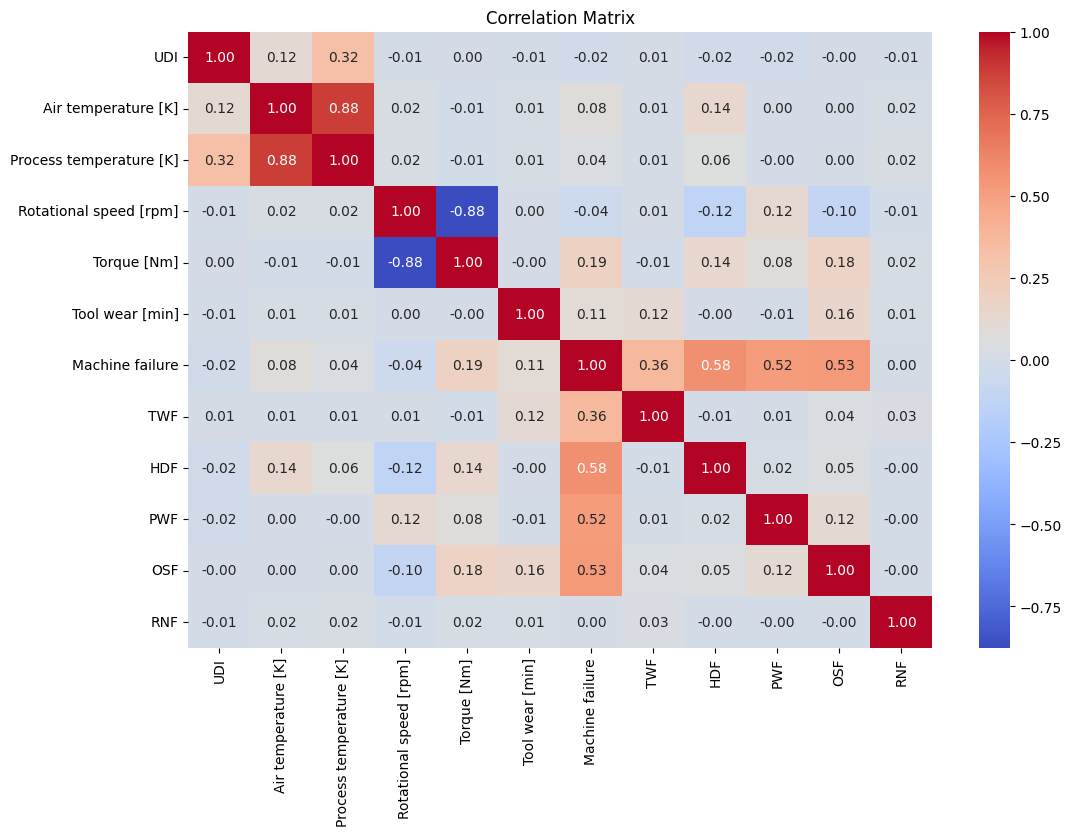

In [6]:
# Correlation matrix
correlation = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

In [5]:
# Check missing values
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


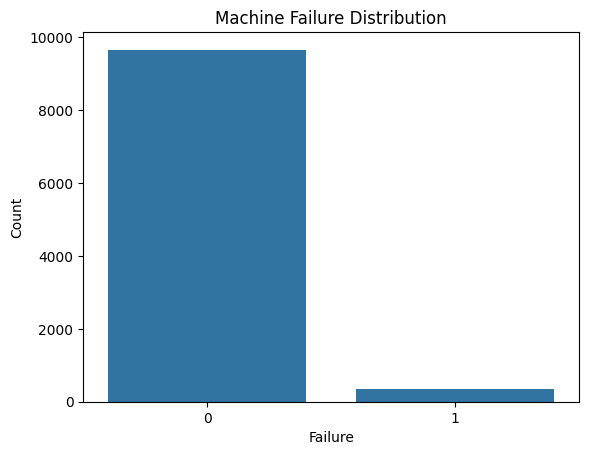

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target distribution
sns.countplot(x="Machine failure", data=df)

plt.title("Machine Failure Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")

plt.show()

In [3]:
# Check target distribution
print(df["Machine failure"].value_counts())

# Normalize percentages
print(df["Machine failure"].value_counts(normalize=True))

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [2]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData types:")
print(df.dtypes)

Shape of dataset: (10000, 14)

Columns:
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/ai4i2020.csv")

# Show first 5 rows
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  